<a href="https://colab.research.google.com/github/Anish-S-tech/deep-learning-journey/blob/main/Image_classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Importing necessary libraries

import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [3]:
# Step 2: Downloading and preparing the dataset

(x_train, y_train), (x_test, y_test)= datasets.cifar10.load_data()

x_train, x_test= x_train/ 255.0, x_test/255.0

num_classes= 10

y_train= to_categorical(y_train, num_classes)
y_test= to_categorical(y_test, num_classes)

In [4]:
# Step 3: Building the CNN model

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation= 'relu', padding= 'same', input_shape= (32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation= 'relu', padding= 'same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation= 'relu', padding= 'same'),
    layers.Flatten(),

    layers.Dense(64, activation= 'relu'),
    layers.Dense(num_classes, activation= 'softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Step 4: Compiling the model

model.compile(optimizer= 'adam', loss= 'categorical_crossentropy', metrics= ['accuracy'])

In [6]:
# Step 5: Training the model

history = model.fit(
    x_train, y_train, epochs= 15,
    batch_size= 64, validation_split= 0.2, verbose= 2
)

Epoch 1/15
625/625 - 78s - 125ms/step - accuracy: 0.4430 - loss: 1.5389 - val_accuracy: 0.5420 - val_loss: 1.2976
Epoch 2/15
625/625 - 83s - 133ms/step - accuracy: 0.5979 - loss: 1.1374 - val_accuracy: 0.6269 - val_loss: 1.0710
Epoch 3/15
625/625 - 85s - 136ms/step - accuracy: 0.6646 - loss: 0.9557 - val_accuracy: 0.6485 - val_loss: 0.9867
Epoch 4/15
625/625 - 76s - 121ms/step - accuracy: 0.7075 - loss: 0.8374 - val_accuracy: 0.6847 - val_loss: 0.9039
Epoch 5/15
625/625 - 78s - 124ms/step - accuracy: 0.7361 - loss: 0.7532 - val_accuracy: 0.6902 - val_loss: 0.8930
Epoch 6/15
625/625 - 80s - 129ms/step - accuracy: 0.7626 - loss: 0.6841 - val_accuracy: 0.7154 - val_loss: 0.8286
Epoch 7/15
625/625 - 82s - 132ms/step - accuracy: 0.7856 - loss: 0.6209 - val_accuracy: 0.7073 - val_loss: 0.8419
Epoch 8/15
625/625 - 75s - 120ms/step - accuracy: 0.8059 - loss: 0.5545 - val_accuracy: 0.7061 - val_loss: 0.8819
Epoch 9/15
625/625 - 76s - 122ms/step - accuracy: 0.8241 - loss: 0.5038 - val_accuracy: 

In [7]:
# Step 6: Evaluating the model

test_loss, test_acc= model.evaluate(x_test, y_test, verbose= 0)

print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.711


In [8]:
# Step 7: Making predictions

predictions= model.predict(x_test)

import numpy as np

print("Predicted class: ", np.argmax(predictions[0]))
print("Actual class: ", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
Predicted class:  3
Actual class:  3


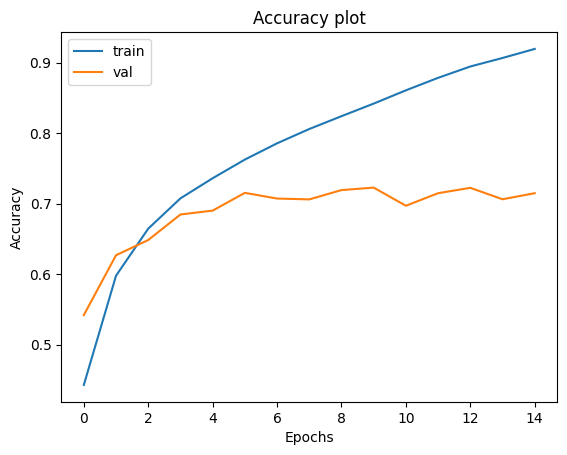

In [9]:
# Step 8: Plotting accuracy curves

plt.plot(history.history['accuracy'], label= 'train')
plt.plot(history.history['val_accuracy'], label= 'val')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy plot")
plt.show()